In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 300
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\UseR\Documents\Data science Assignment\EDA2\EDA2\adult_with_headers.csv", sep=',', skipinitialspace=True)

In [3]:
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
df.shape

(32561, 15)

In [5]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# 1. Data Exploration and Preprocessing:

In [6]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
32556    False
32557    False
32558    False
32559    False
32560    False
Length: 32561, dtype: bool

In [7]:
df.duplicated().sum()

24

In [8]:
#Drop duplicate records

In [9]:
df.drop_duplicates(inplace = True)

In [10]:
df.duplicated().sum()

0

# Missing values

In [11]:
#checking null values

In [12]:
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [13]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [14]:
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

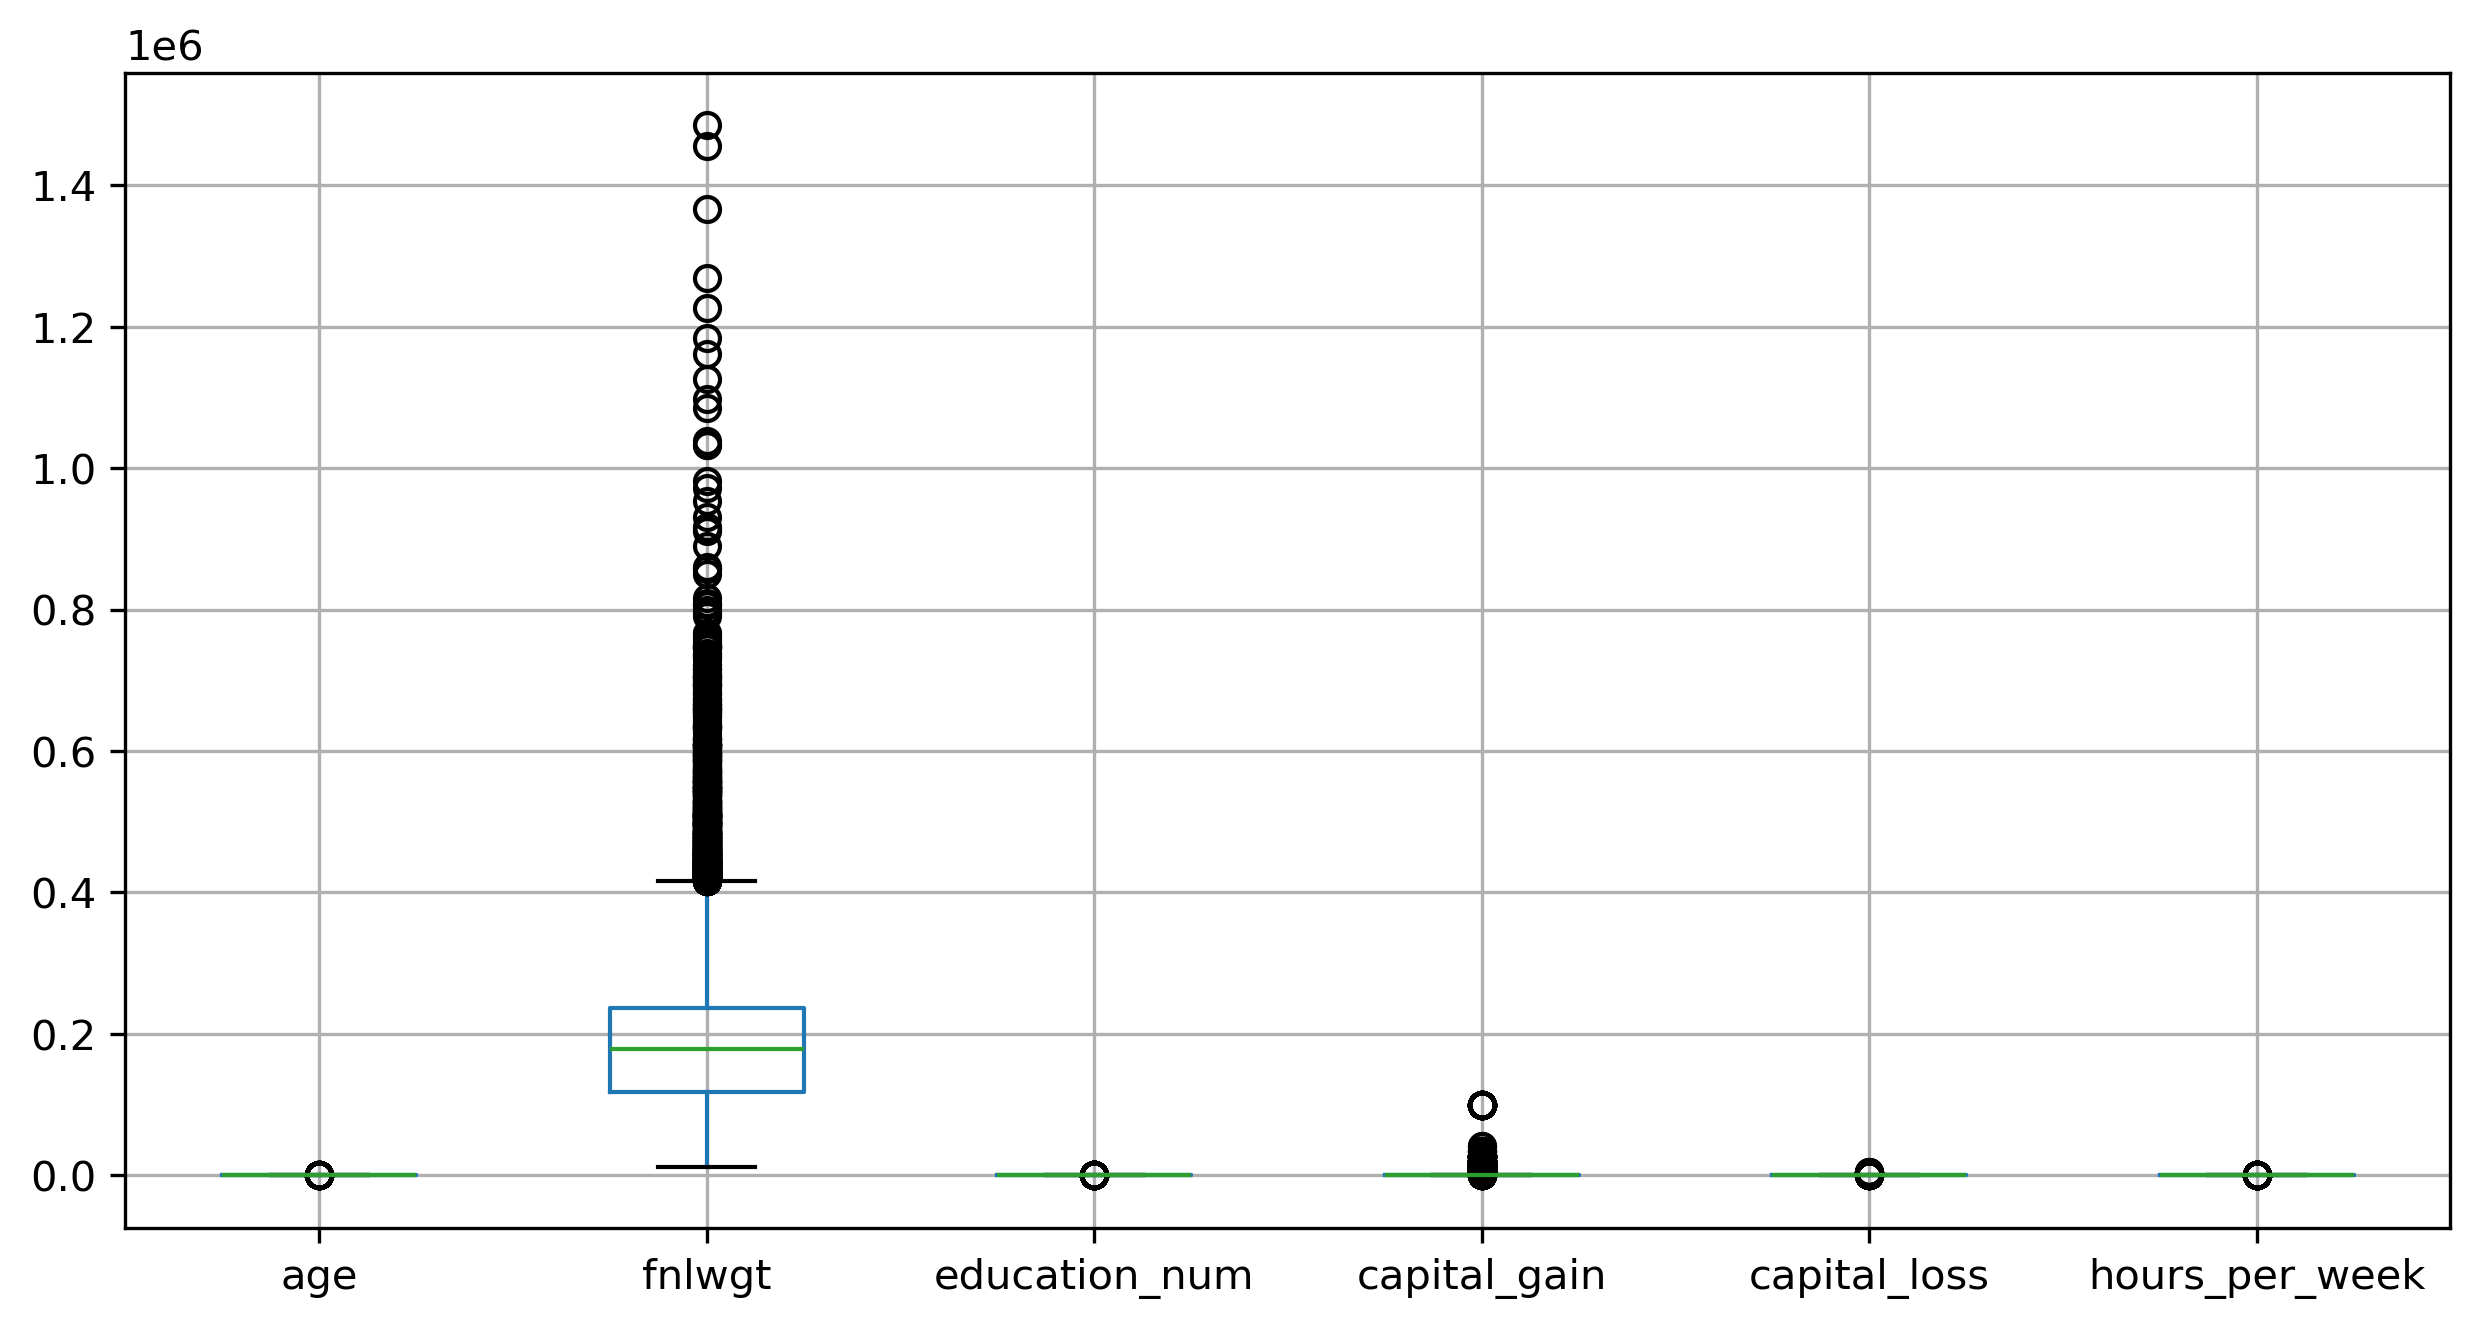

In [15]:
df.boxplot()
plt.show()

In [23]:
import numpy as np

def capping(df, columns):
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - (1.5 * iqr)
        upper = q3 + (1.5 * iqr)

        df[col] = np.where(df[col] > upper, upper, 
                             np.where(df[col] < lower, lower, df[col]))

In [20]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
capping(df, numeric_cols)


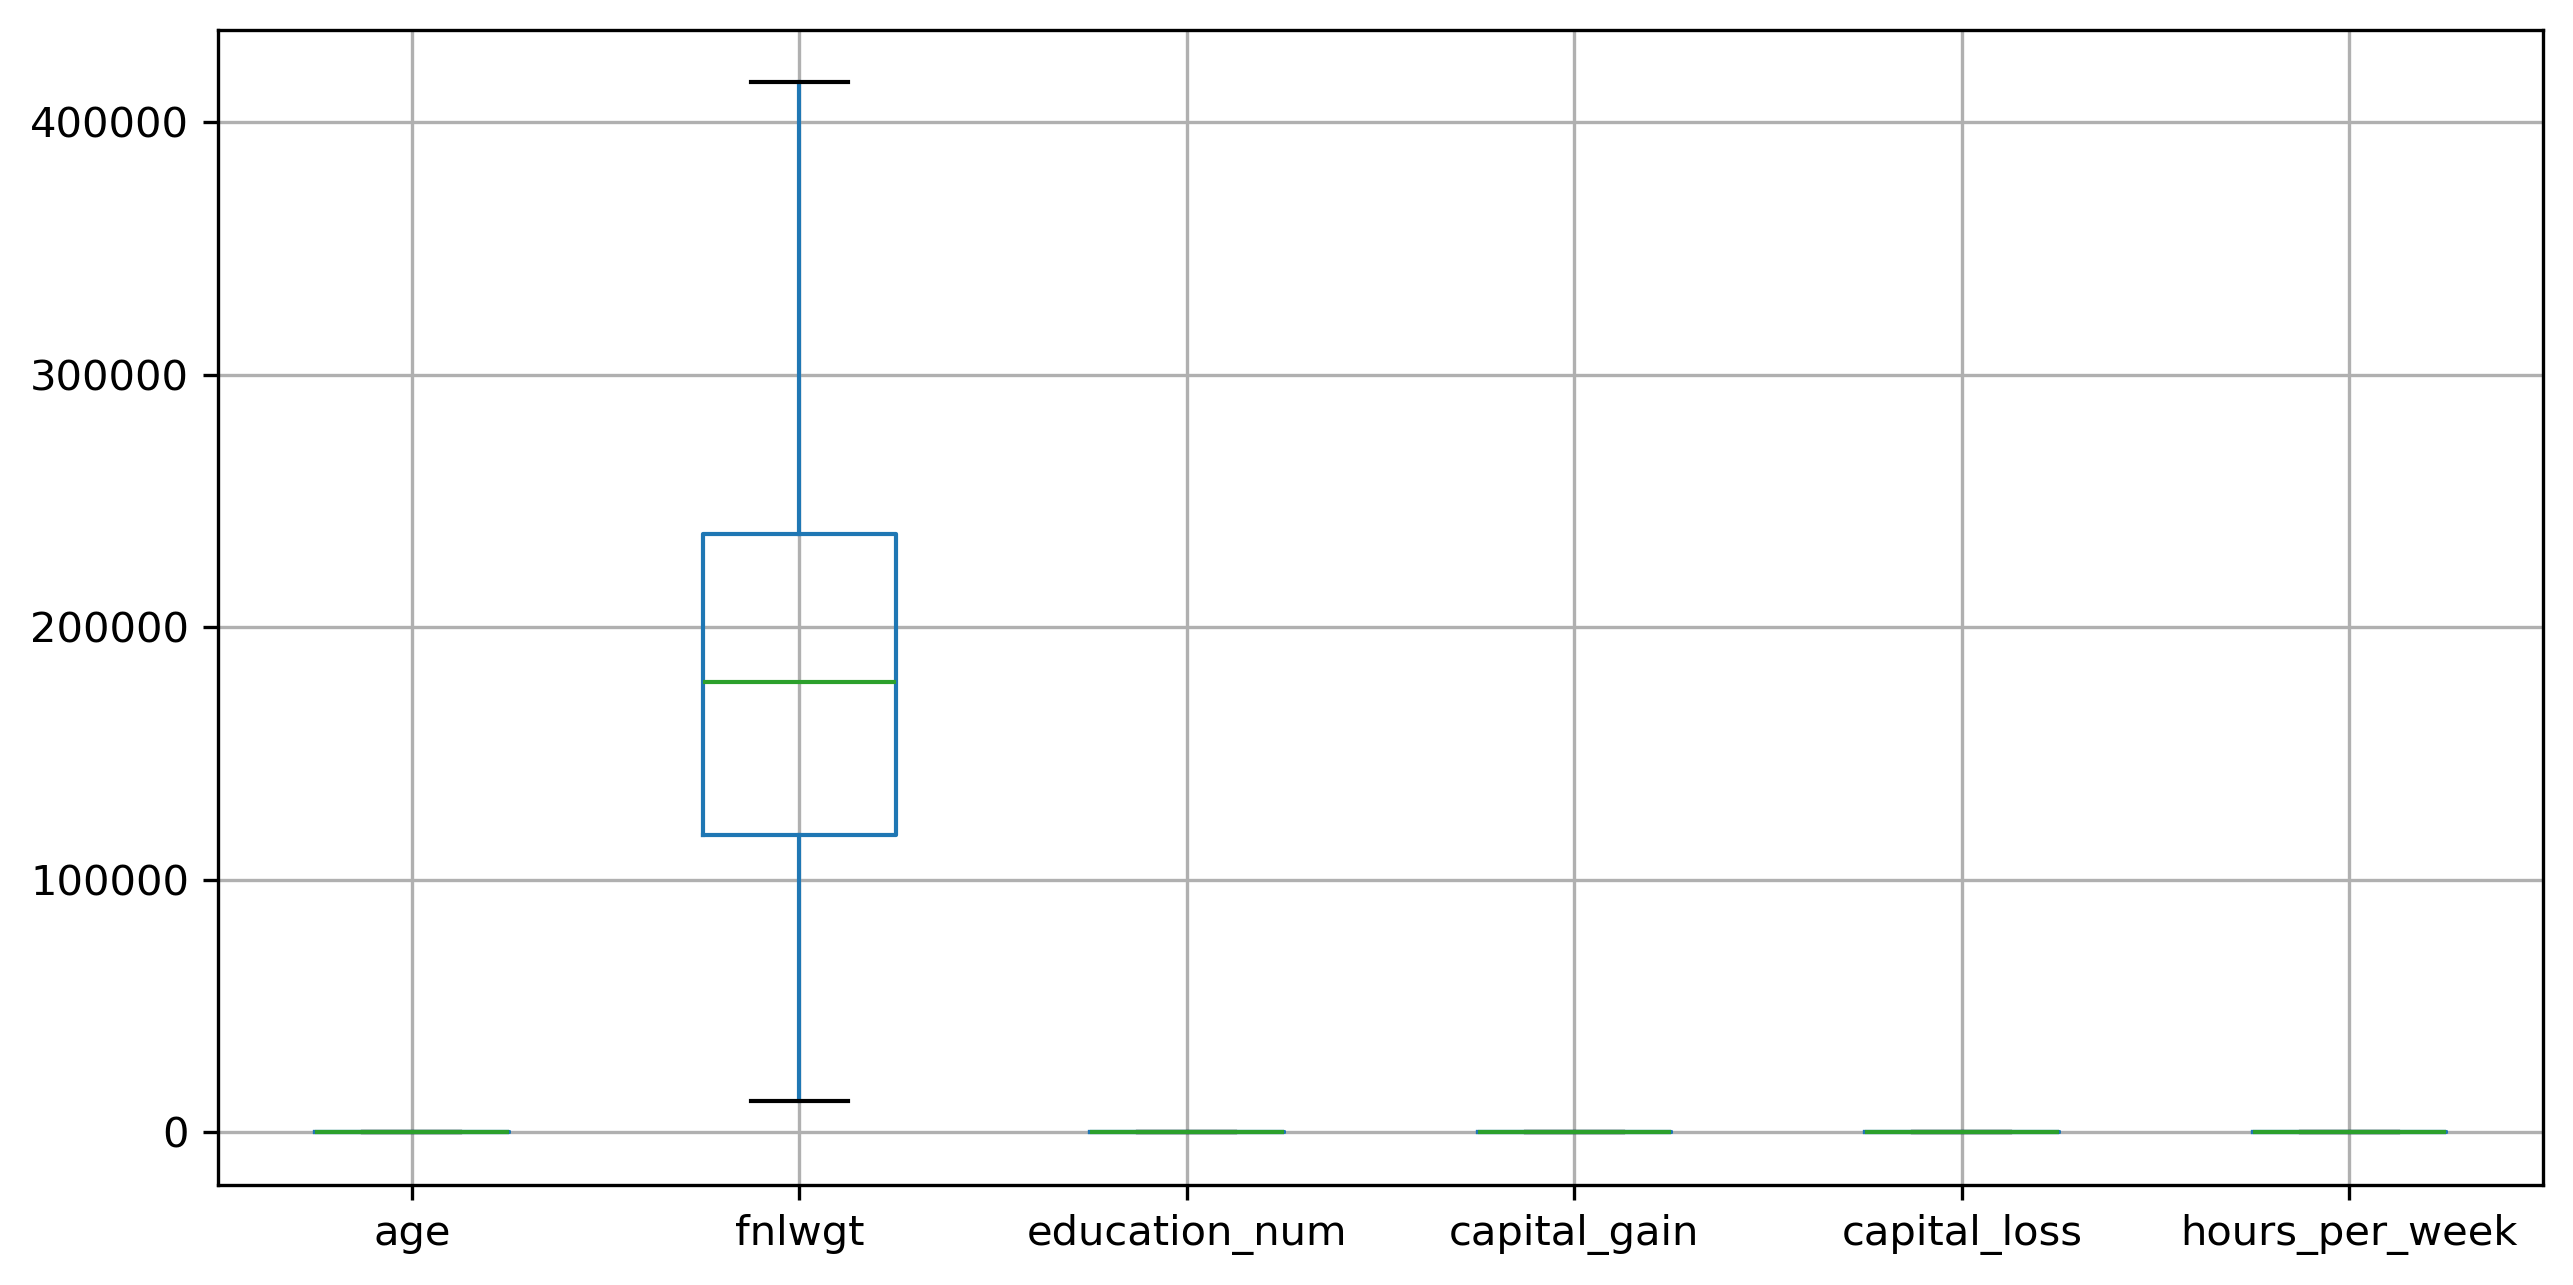

In [21]:
df.boxplot()
plt.show()

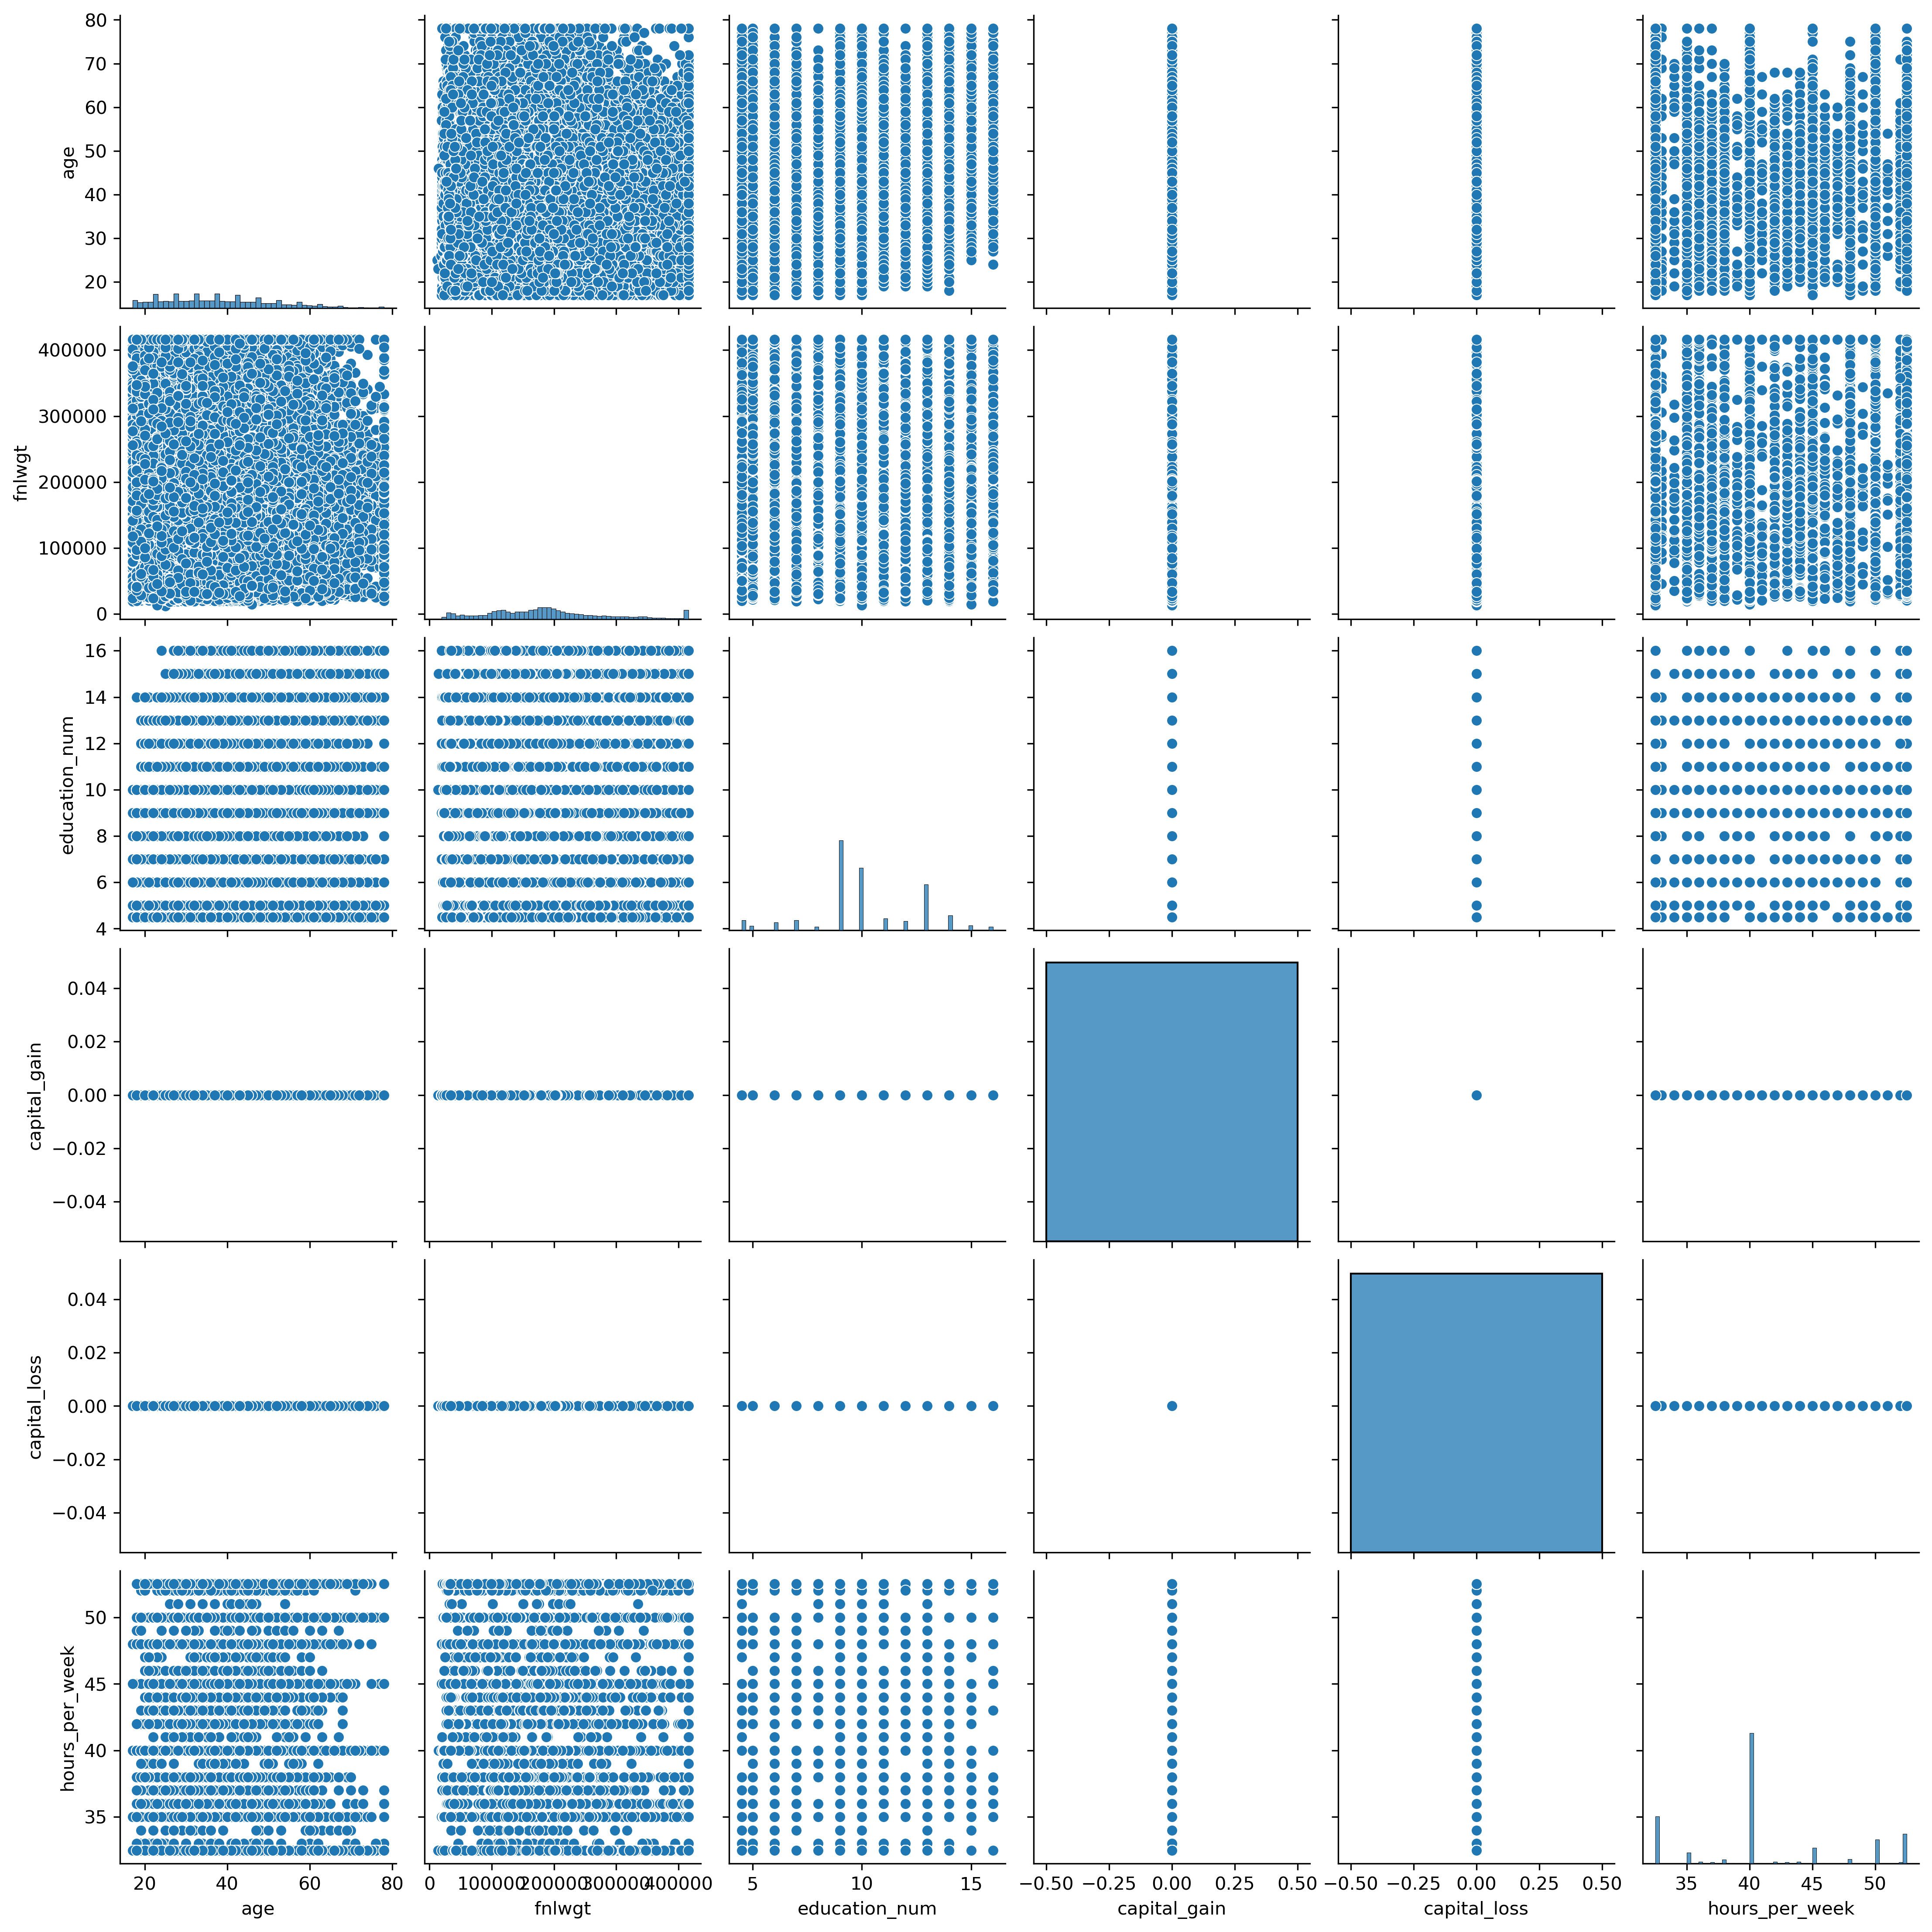

In [22]:
sns.pairplot(df)
plt.show()

# correlation coefficient

In [24]:
df.corr(numeric_only = True)

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
age,1.000000,-0.077169,0.047012,NaN,NaN,0.091242
fnlwgt,-0.077169,1.000000,-0.039794,NaN,NaN,-0.025753
education_num,0.047012,-0.039794,1.000000,NaN,NaN,0.184978
capital_gain,NaN,NaN,NaN,NaN,NaN,NaN
capital_loss,NaN,NaN,NaN,NaN,NaN,NaN
hours_per_week,0.091242,-0.025753,0.184978,NaN,NaN,1.000000


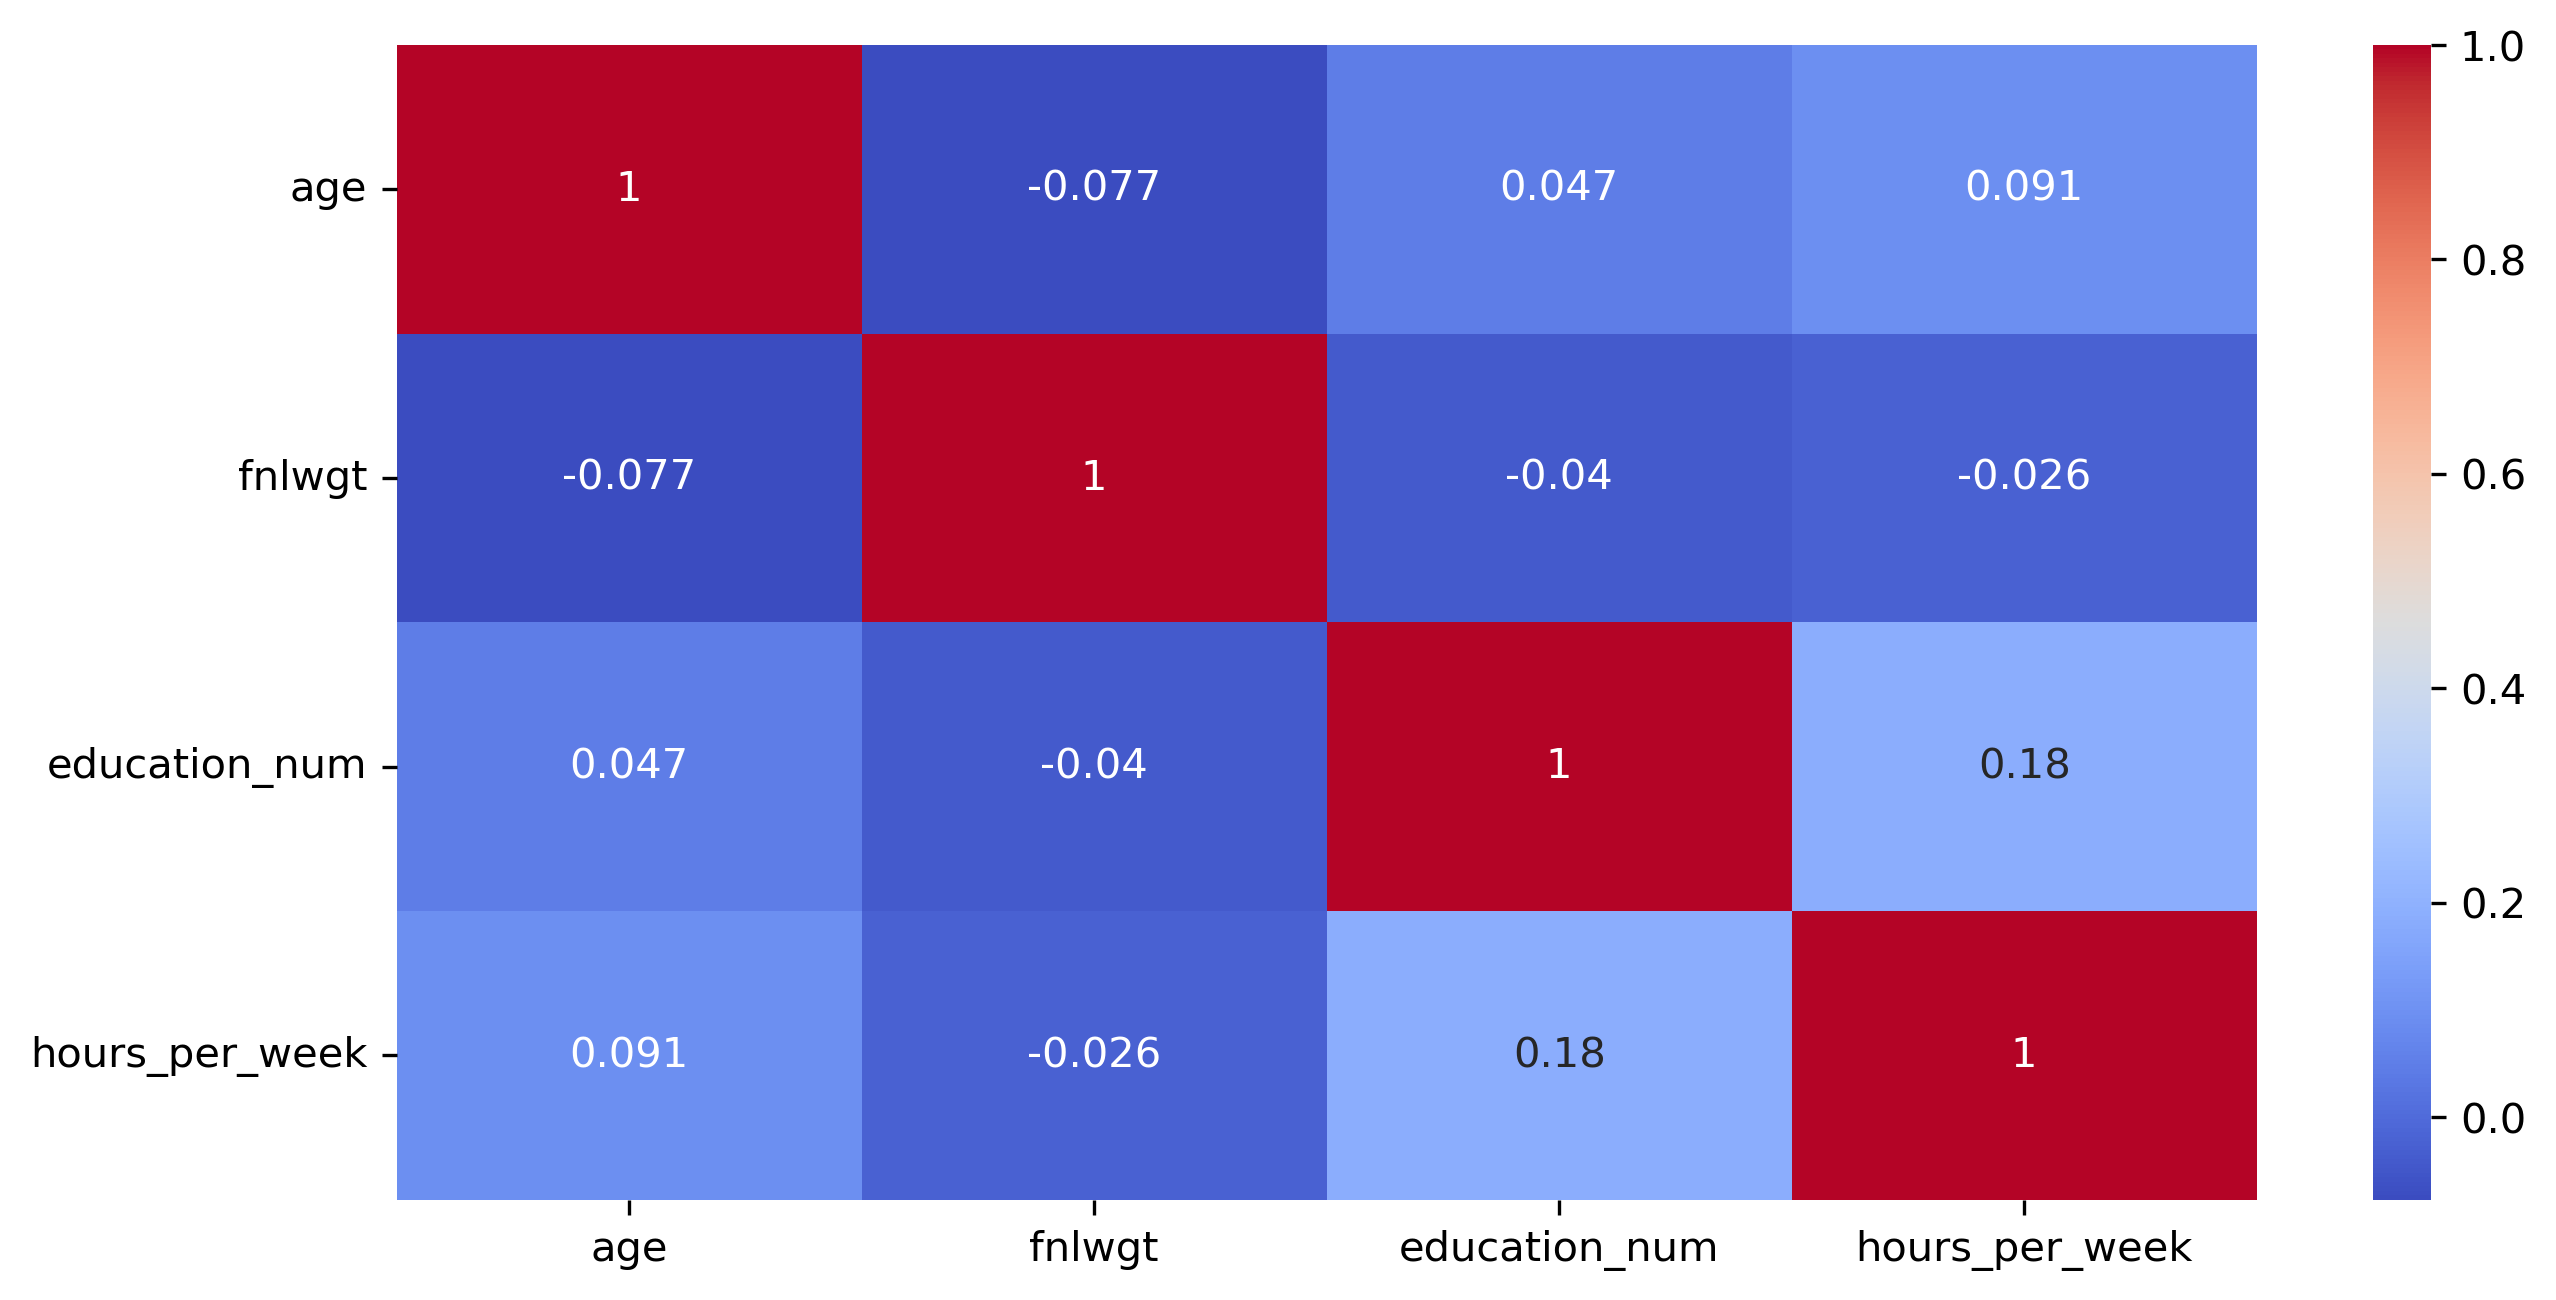

In [25]:
# Drop constant columns (only 1 unique value)
df = df.loc[:, df.nunique() > 1]

# Now plot correlation
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


# Transformation

# 2. Encoding Techniques:

In [29]:
from sklearn.preprocessing import LabelEncoder

# Step 2: Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Step 3: Apply encoding based on number of unique values
label_encoder = LabelEncoder()

for col in categorical_cols:
    unique_vals = df[col].nunique()
    
    if unique_vals < 5:
        # One-Hot Encoding for columns with less than 5 unique values
        df = pd.get_dummies(df, columns=[col], drop_first=True)
    else:
        # Label Encoding for columns with 5 or more unique values
        df[col] = label_encoder.fit_transform(df[col])

# Step 4: Check the final DataFrame
print(df.head())


# Convert boolean columns to integers (0 and 1)
df['sex_Male'] = df['sex_Male'].astype(int)
df['income_>50K'] = df['income_>50K'].astype(int)


    age  workclass    fnlwgt  education  education_num  marital_status  \
0  39.0          7   77516.0          9           13.0               4   
1  50.0          6   83311.0          9           13.0               2   
2  38.0          4  215646.0         11            9.0               0   
3  53.0          4  234721.0          1            7.0               2   
4  28.0          4  338409.0          9           13.0               2   

   occupation  relationship  race  hours_per_week  native_country  sex_Male  \
0           1             1     4            40.0              39      True   
1           4             0     4            32.5              39      True   
2           6             1     4            40.0              39      True   
3           6             0     2            40.0              39      True   
4          10             5     2            40.0               5     False   

   income_>50K  
0        False  
1        False  
2        False  
3        Fal

In [30]:
#•	Applied One-Hot Encoding to categorical variables with less than 5 categories.
#•	Used Label Encoding for categorical variables with more than 5 categories.


# The pros and cons of One-Hot Encoding and Label Encoding.

# One-Hot Encoding
✅ Pros:

No Ordinal Assumption: Treats all categories as equal — ideal when there's no natural order (e.g., country, color, occupation).

Compatible with Linear Models: Prevents the model from assuming one value is “greater” than another.

Improves model accuracy: Often better for algorithms that are sensitive to numerical magnitudes (e.g., Logistic Regression, KNN).

❌ Cons:

High Dimensionality: Can create many new columns for variables with many categories (high cardinality).

Memory/Computation Cost: Sparse matrix with lots of 0s; can slow down training.

Risk of Overfitting: Especially with small datasets and many dummy variables.

# 🔹 Label Encoding
✅ Pros:

Simple and Efficient: Only one column is created per variable, no extra memory used.

Useful for Tree-based Models: Decision Trees, Random Forest, and XGBoost handle label-encoded data very well.

Faster to apply: Especially useful in automated pipelines.

❌ Cons:

Creates Ordinal Relationship: Assigns an artificial order (e.g., A=0, B=1, C=2), which can mislead models like Logistic Regression or Linear Regression.

Can confuse models: Models may interpret higher labels as more important even when they're not.

# •	Apply scaling techniques to numerical features:

In [31]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## •	Standard Scaling

In [32]:
sc = StandardScaler()

In [33]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,hours_per_week,native_country,sex_Male,income_>50K
0,39.0,7,77516.0,9,13.0,4,1,1,4,40.0,39,1,0
1,50.0,6,83311.0,9,13.0,2,4,0,4,32.5,39,1,0
2,38.0,4,215646.0,11,9.0,0,6,1,4,40.0,39,1,0
3,53.0,4,234721.0,1,7.0,2,6,0,2,40.0,39,1,0
4,28.0,4,338409.0,9,13.0,2,10,5,2,40.0,5,0,0


In [34]:
sc.fit_transform(df)

array([[ 0.03247191,  2.14997135, -1.1492095 , ...,  0.29133547,
         0.70301957, -0.56337742],
       [ 0.8440022 ,  1.46335725, -1.08828431, ...,  0.29133547,
         0.70301957, -0.56337742],
       [-0.04130357,  0.09012905,  0.30300728, ...,  0.29133547,
         0.70301957, -0.56337742],
       ...,
       [ 1.43420604,  0.09012905, -0.36707517, ...,  0.29133547,
        -1.42243552, -0.56337742],
       [-1.22171125,  0.09012905,  0.1541795 , ...,  0.29133547,
         0.70301957, -0.56337742],
       [ 0.99155316,  0.77674315,  1.06292678, ...,  0.29133547,
        -1.42243552,  1.77500901]])

In [35]:
scaled_data = pd.DataFrame(sc.fit_transform(df), columns = df.columns)
scaled_data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,hours_per_week,native_country,sex_Male,income_>50K
0,0.032472,2.149971,-1.149209,-0.335266,1.168918,0.921857,-1.317629,-0.277864,0.393685,-0.194472,0.291335,0.703020,-0.563377
1,0.844002,1.463357,-1.088284,-0.335266,1.168918,-0.405919,-0.608318,-0.900126,0.393685,-1.406640,0.291335,0.703020,-0.563377
2,-0.041304,0.090129,0.303007,0.181519,-0.457496,-1.733696,-0.135444,-0.277864,0.393685,-0.194472,0.291335,0.703020,-0.563377
3,1.065329,0.090129,0.503550,-2.402406,-1.270703,-0.405919,-0.135444,-0.900126,-1.962488,-0.194472,0.291335,0.703020,-0.563377
4,-0.779058,0.090129,1.593665,-0.335266,1.168918,-0.405919,0.810304,2.211186,-1.962488,-0.194472,-4.056151,-1.422436,-0.563377
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32532,-0.852834,0.090129,0.740954,-0.852051,0.762315,-0.405919,1.519615,2.211186,0.393685,-0.517717,0.291335,-1.422436,-0.563377
32533,0.106247,0.090129,-0.341170,0.181519,-0.457496,-0.405919,0.100993,-0.900126,0.393685,-0.194472,0.291335,0.703020,1.775009
32534,1.434206,0.090129,-0.367075,0.181519,-0.457496,2.249634,-1.317629,1.588923,0.393685,-0.194472,0.291335,-1.422436,-0.563377
32535,-1.221711,0.090129,0.154180,0.181519,-0.457496,0.921857,-1.317629,0.966661,0.393685,-1.406640,0.291335,0.703020,-0.563377


In [36]:
scaled_data.describe()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,hours_per_week,native_country,sex_Male,income_>50K
count,3.253700e+04,3.253700e+04,3.253700e+04,3.253700e+04,3.253700e+04,3.253700e+04,3.253700e+04,3.253700e+04,3.253700e+04,3.253700e+04,3.253700e+04,3.253700e+04,3.253700e+04
mean,1.489351e-16,-3.494079e-17,5.568688e-18,3.712459e-17,3.173060e-16,1.026386e-17,6.944481e-17,-5.961772e-17,-1.838759e-16,-2.292989e-16,3.590166e-16,7.130104e-17,-4.367598e-19
std,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,-1.590589e+00,-2.656327e+00,-1.835009e+00,-2.660798e+00,-2.287212e+00,-1.733696e+00,-1.554066e+00,-9.001260e-01,-4.318661e+00,-1.406640e+00,-4.695487e+00,-1.422436e+00,-5.633774e-01
25%,-7.790584e-01,9.012905e-02,-7.254036e-01,-3.352661e-01,-4.574962e-01,-4.059193e-01,-8.447553e-01,-9.001260e-01,3.936852e-01,-1.944716e-01,2.913355e-01,-1.422436e+00,-5.633774e-01
50%,-1.150790e-01,9.012905e-02,-8.903763e-02,1.815188e-01,-5.089262e-02,-4.059193e-01,1.009928e-01,-2.778636e-01,3.936852e-01,-1.944716e-01,2.913355e-01,7.030196e-01,-5.633774e-01
75%,6.964512e-01,9.012905e-02,5.274370e-01,4.399112e-01,7.623146e-01,9.218575e-01,8.103039e-01,9.666610e-01,3.936852e-01,6.136409e-01,2.913355e-01,7.030196e-01,-5.633774e-01
max,2.909716e+00,2.836585e+00,2.406698e+00,1.215089e+00,2.388729e+00,2.249634e+00,1.756052e+00,2.211186e+00,3.936852e-01,1.825810e+00,5.470700e-01,7.030196e-01,1.775009e+00


# •	Min-Max Scaling

In [37]:
mn = MinMaxScaler()

In [38]:
minmax_scaled = pd.DataFrame(mn.fit_transform(df), columns = df.columns)

In [39]:
minmax_scaled

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,hours_per_week,native_country,sex_Male,income_>50K
0,0.360656,0.875,0.161680,0.600000,0.739130,0.666667,0.071429,0.2,1.0,0.375,0.951220,1.0,0.0
1,0.540984,0.750,0.176044,0.600000,0.739130,0.333333,0.285714,0.0,1.0,0.000,0.951220,1.0,0.0
2,0.344262,0.500,0.504046,0.733333,0.391304,0.000000,0.428571,0.2,1.0,0.375,0.951220,1.0,0.0
3,0.590164,0.500,0.551325,0.066667,0.217391,0.333333,0.428571,0.0,0.5,0.375,0.951220,1.0,0.0
4,0.180328,0.500,0.808324,0.600000,0.739130,0.333333,0.714286,1.0,0.5,0.375,0.121951,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32532,0.163934,0.500,0.607294,0.466667,0.652174,0.333333,0.928571,1.0,1.0,0.275,0.951220,0.0,0.0
32533,0.377049,0.500,0.352179,0.733333,0.391304,0.333333,0.500000,0.0,1.0,0.375,0.951220,1.0,1.0
32534,0.672131,0.500,0.346072,0.733333,0.391304,1.000000,0.071429,0.8,1.0,0.375,0.951220,0.0,0.0
32535,0.081967,0.500,0.468960,0.733333,0.391304,0.666667,0.071429,0.6,1.0,0.000,0.951220,1.0,0.0


In [40]:
minmax_scaled.describe()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,hours_per_week,native_country,sex_Male,income_>50K
count,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000
mean,0.353440,0.483592,0.432611,0.686500,0.489145,0.435238,0.469490,0.289308,0.916457,0.435162,0.895648,0.669238,0.240926
std,0.222211,0.182056,0.235758,0.258009,0.213864,0.251050,0.302109,0.321413,0.212212,0.309368,0.190750,0.470495,0.427652
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.180328,0.500000,0.261594,0.600000,0.391304,0.333333,0.214286,0.000000,1.000000,0.375000,0.951220,0.000000,0.000000
50%,0.327869,0.500000,0.411620,0.733333,0.478261,0.333333,0.500000,0.200000,1.000000,0.375000,0.951220,1.000000,0.000000
75%,0.508197,0.500000,0.556957,0.800000,0.652174,0.666667,0.714286,0.600000,1.000000,0.625000,0.951220,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 3. Feature Engineering:
•	Create at least 2 new features that could be beneficial for the model. Explain the rationale               behind your choices.

# 1. workload_per_education_level

In [41]:
df['workload_per_education_level'] = df['hours_per_week'] / (df['education_num'] + 1)
df['workload_per_education_level']

0        2.857143
1        2.321429
2        4.000000
3        5.000000
4        2.857143
           ...   
32556    2.923077
32557    4.000000
32558    4.000000
32559    3.250000
32560    4.000000
Name: workload_per_education_level, Length: 32537, dtype: float64

### * This feature shows how many hours a person works per level of education.
### * People with higher education might work fewer hours but earn more — this ratio could reveal such patterns and help the model distinguish high-earning educated professionals vs. low-earning overworked individuals.

# 2. is_working_full_time

In [42]:
df['is_working_full_time'] = (df['hours_per_week'] >= 40).astype(int)


In [43]:
df['is_working_full_time']

0        1
1        0
2        1
3        1
4        1
        ..
32556    0
32557    1
32558    1
32559    0
32560    1
Name: is_working_full_time, Length: 32537, dtype: int32

### * This binary feature marks whether someone works full-time (40+ hours).

### * Full-time workers are more likely to earn over $50K than part-time workers.

In [44]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,hours_per_week,native_country,sex_Male,income_>50K,workload_per_education_level,is_working_full_time
0,39.0,7,77516.0,9,13.0,4,1,1,4,40.0,39,1,0,2.857143,1
1,50.0,6,83311.0,9,13.0,2,4,0,4,32.5,39,1,0,2.321429,0
2,38.0,4,215646.0,11,9.0,0,6,1,4,40.0,39,1,0,4.000000,1
3,53.0,4,234721.0,1,7.0,2,6,0,2,40.0,39,1,0,5.000000,1
4,28.0,4,338409.0,9,13.0,2,10,5,2,40.0,5,0,0,2.857143,1


# * Applied a transformation 

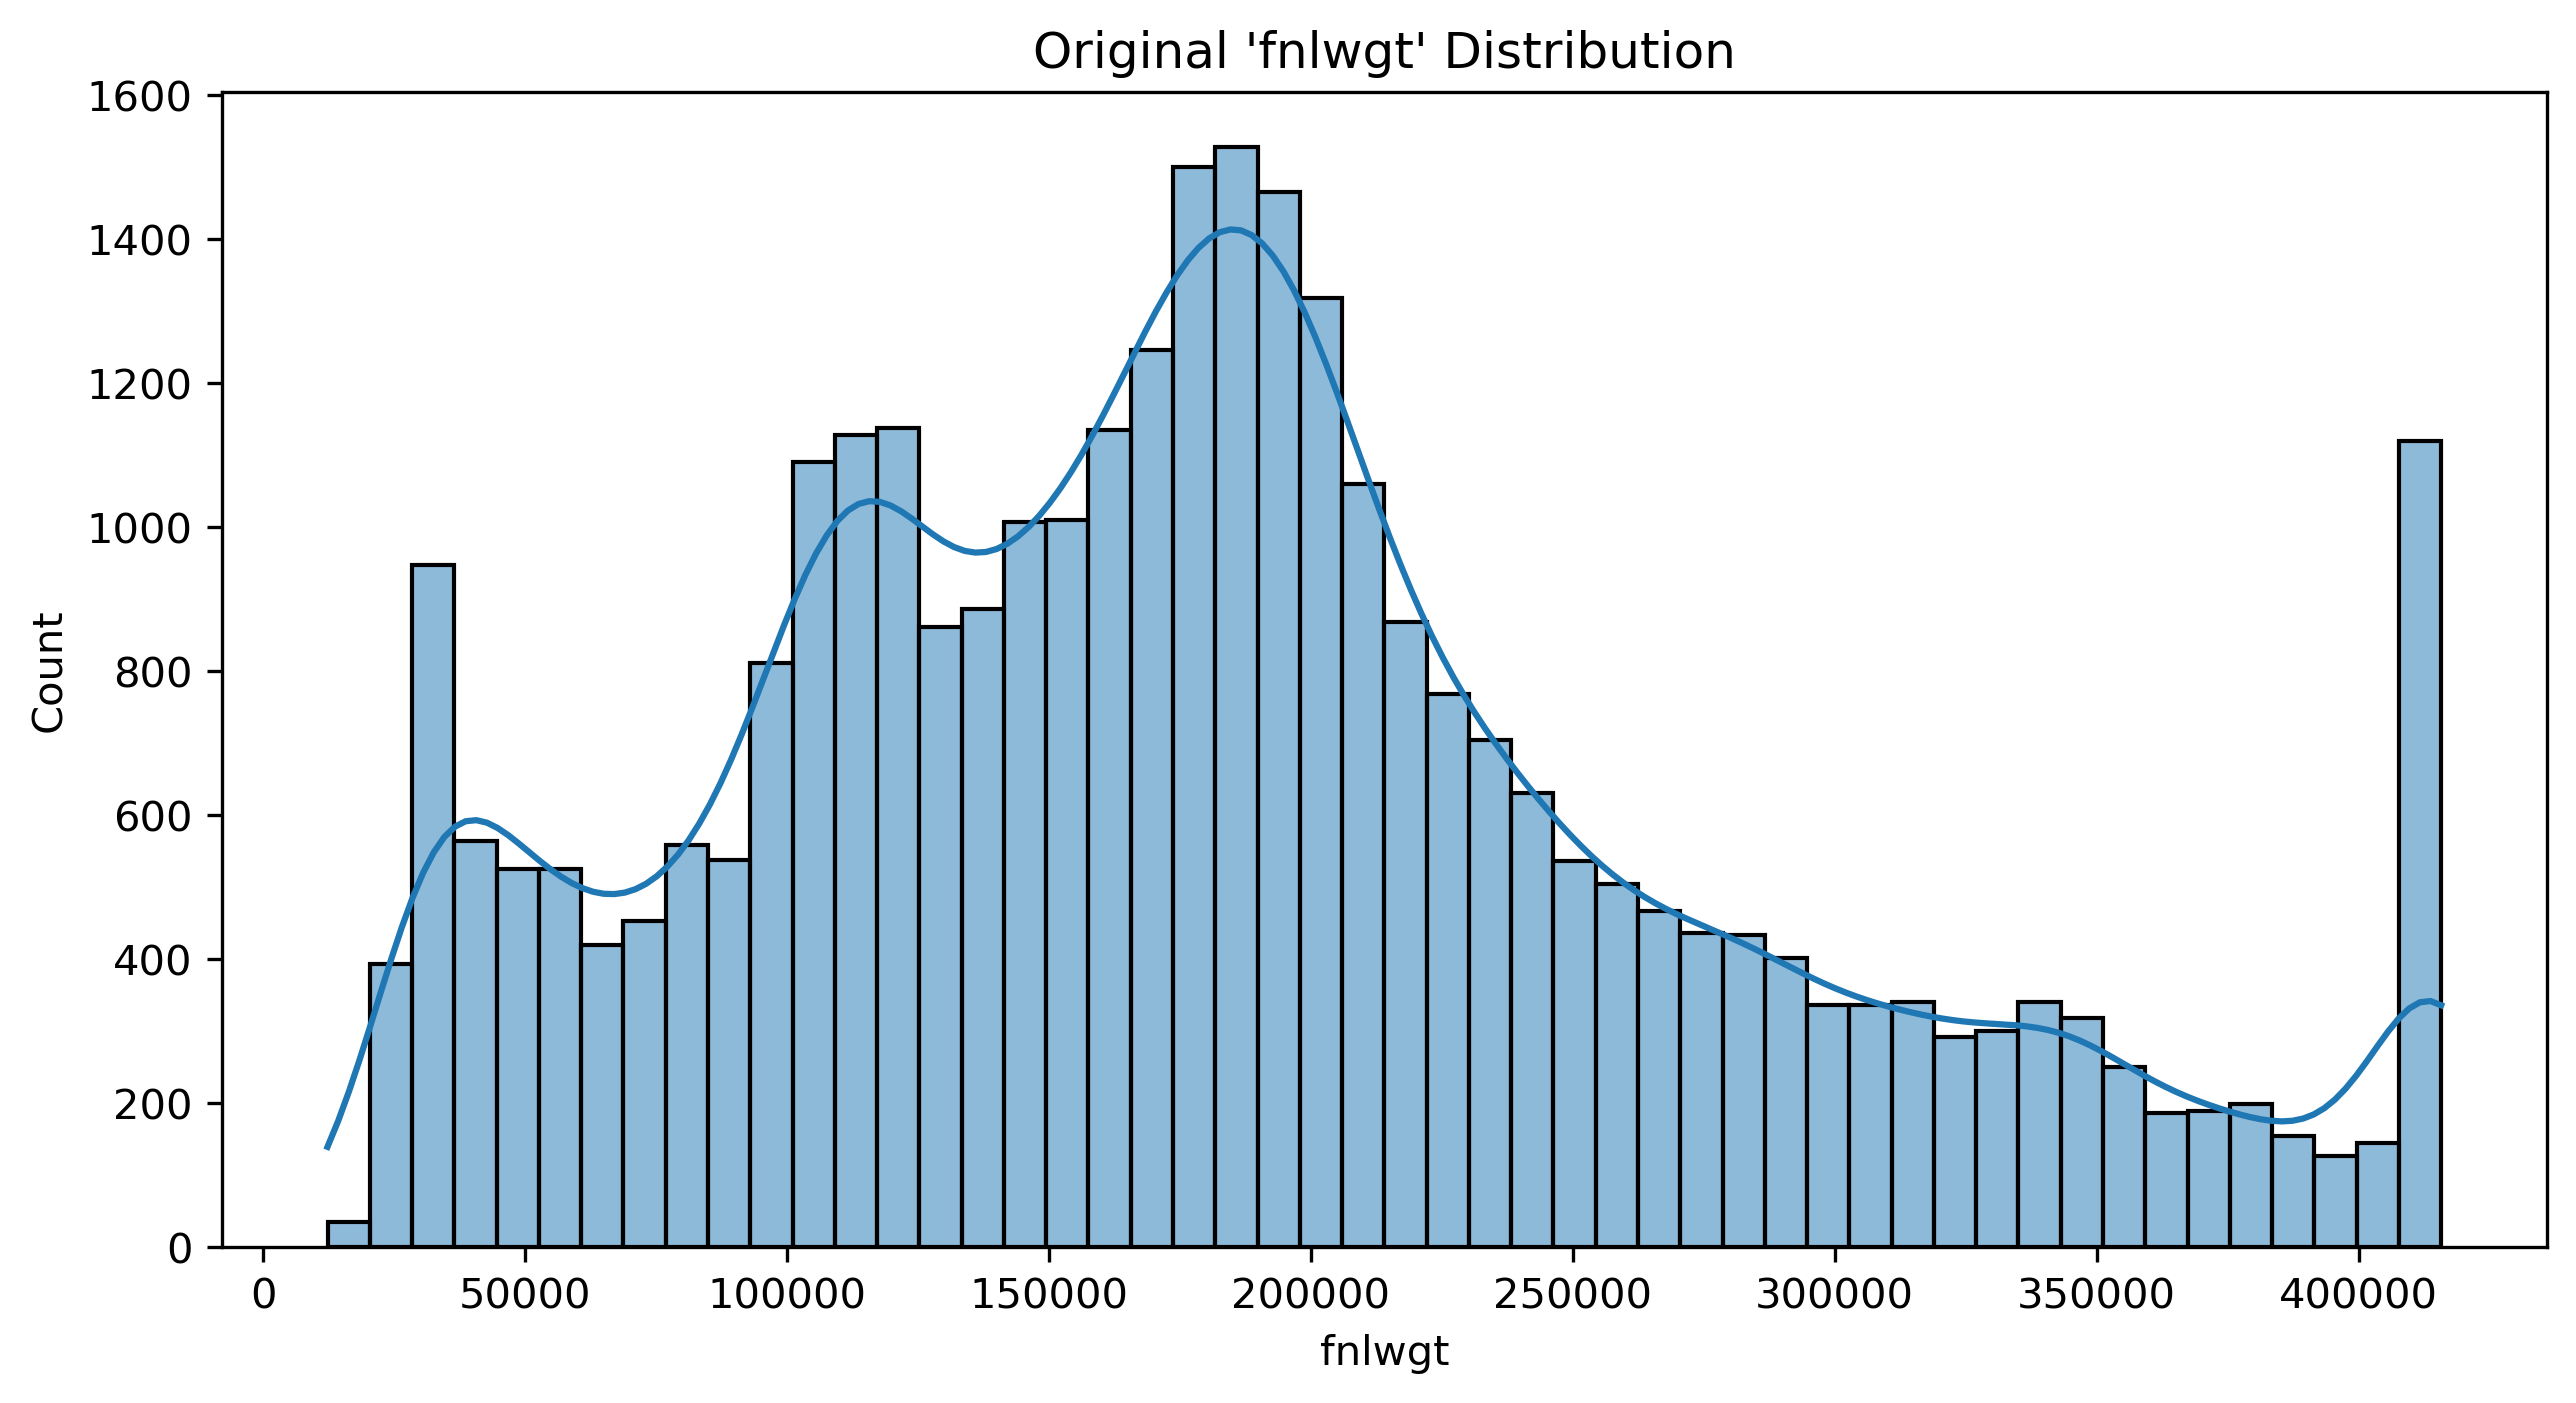

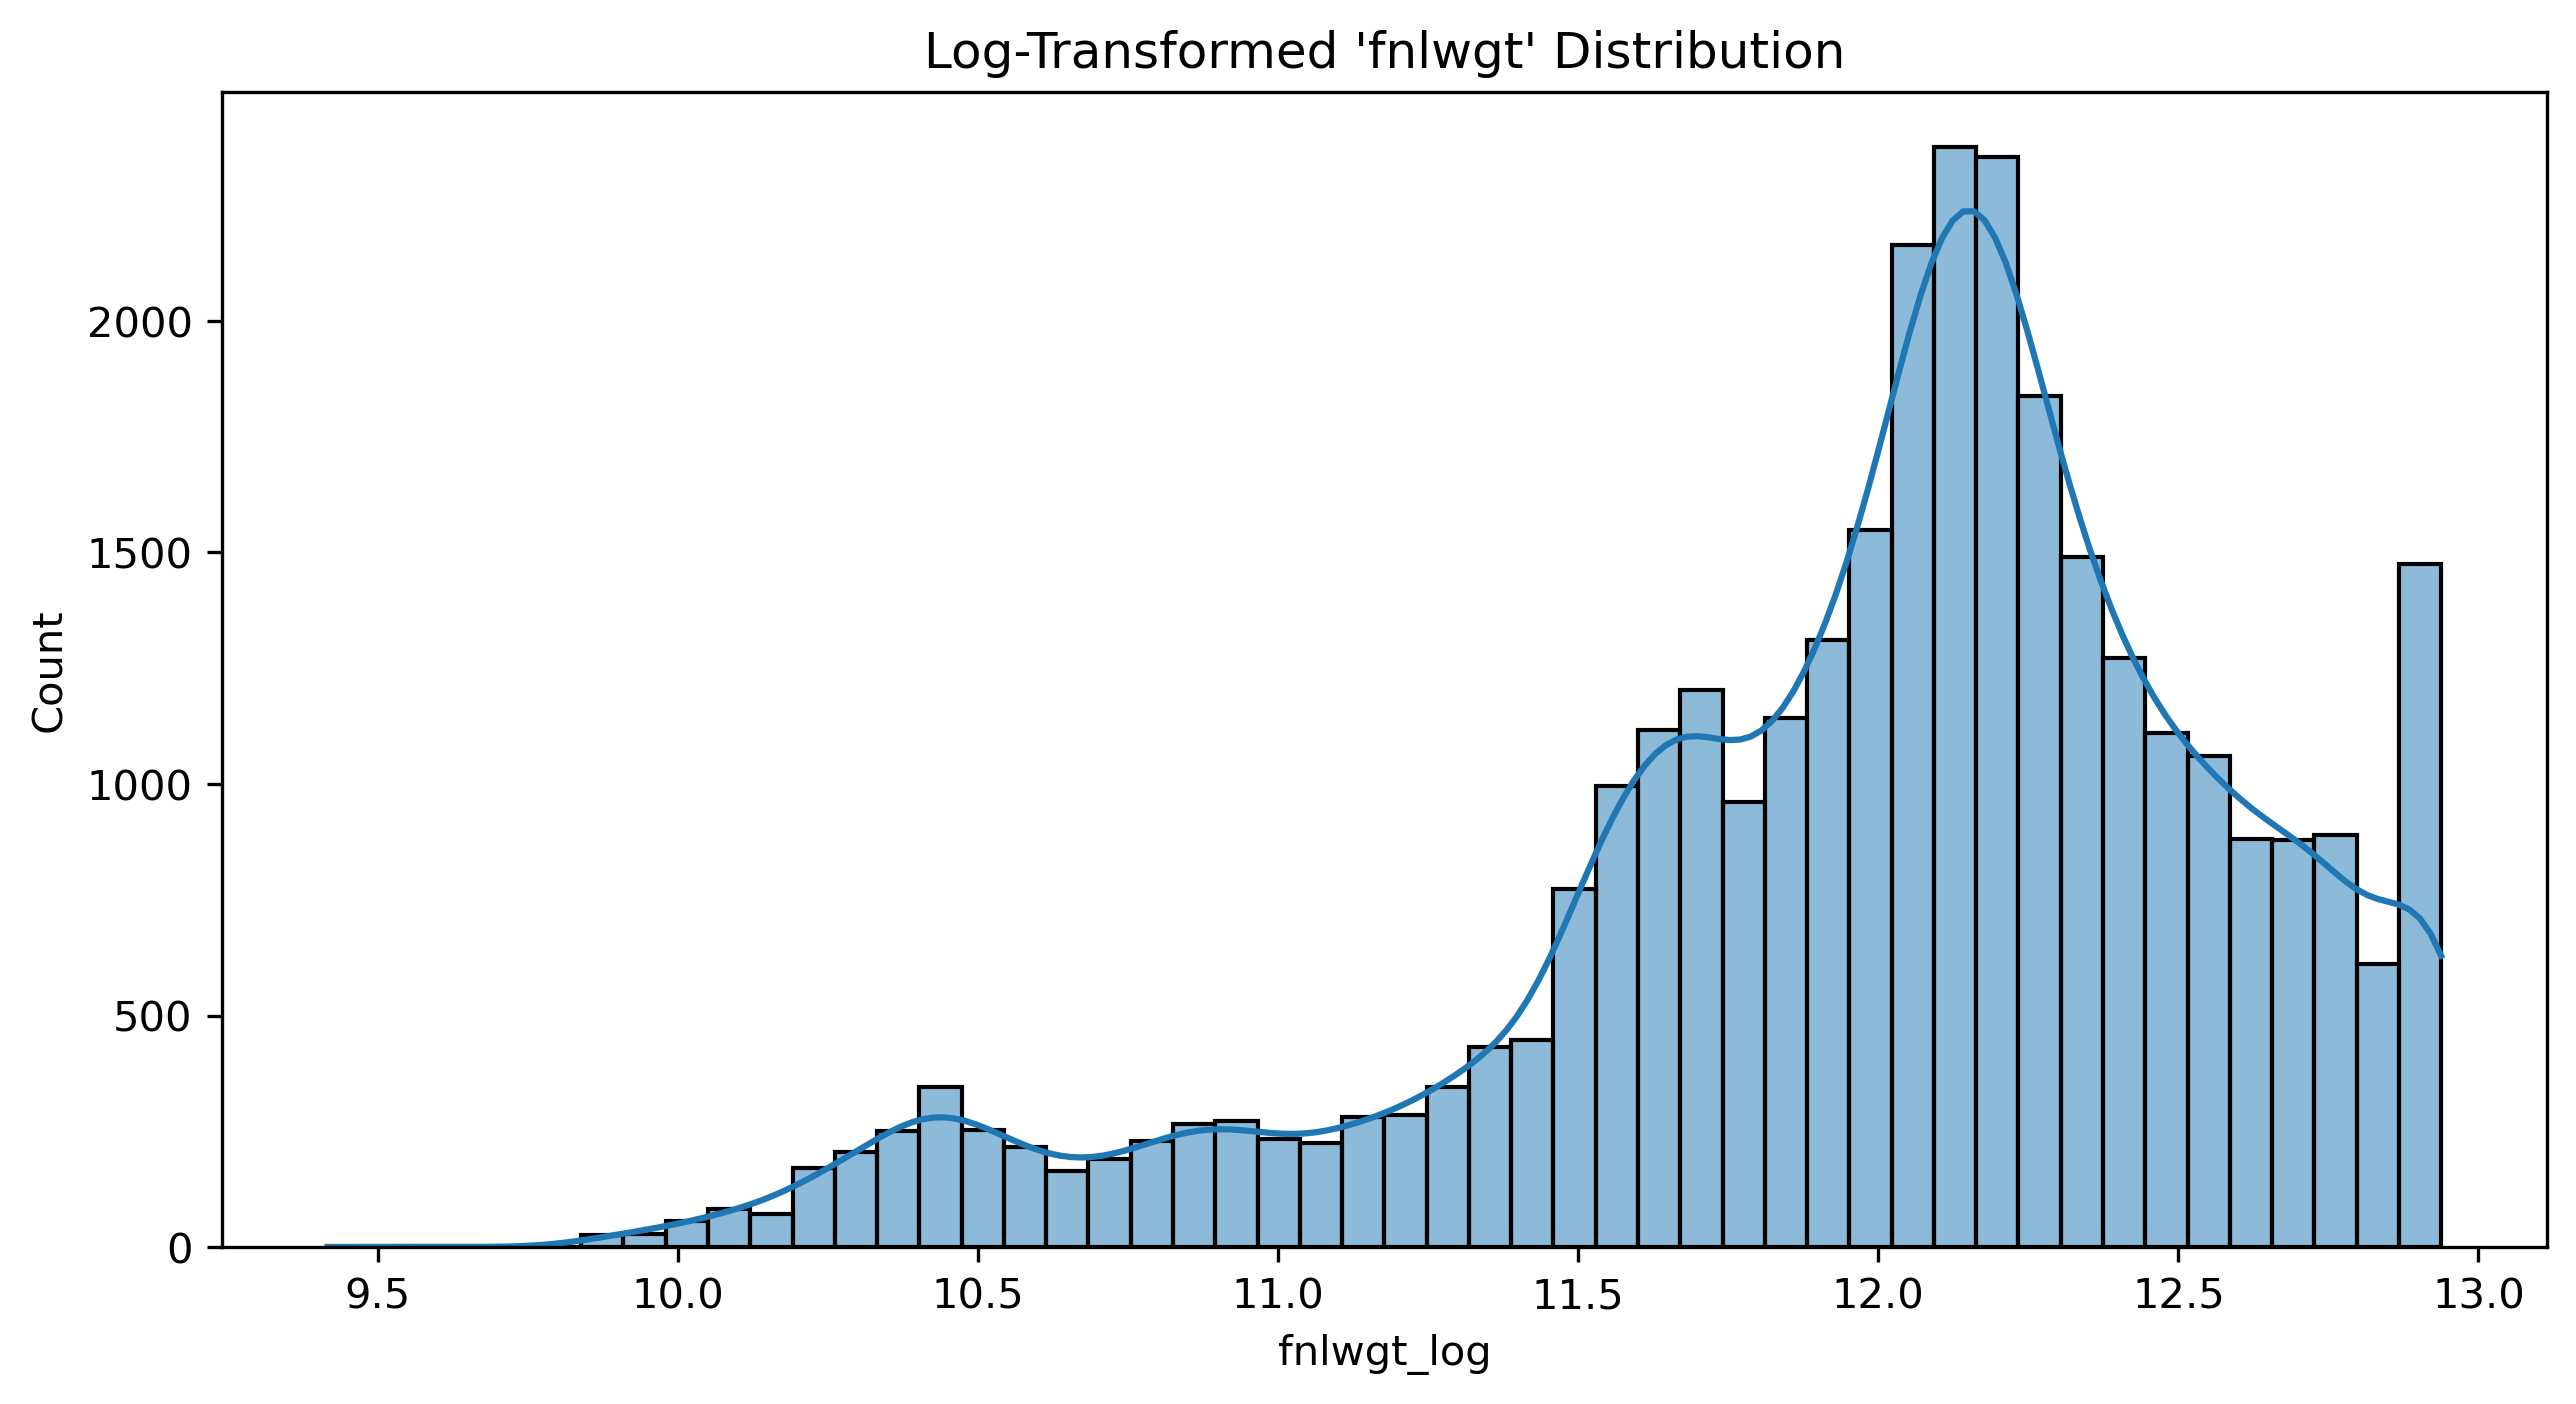

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Before transformation
sns.histplot(df['fnlwgt'], bins=50, kde=True)
plt.title("Original 'fnlwgt' Distribution")
plt.show()

# After transformation
sns.histplot(df['fnlwgt_log'], bins=50, kde=True)
plt.title("Log-Transformed 'fnlwgt' Distribution")
plt.show()


### Right-skewed distributions (like fnlwgt) can distort model performance, especially in linear models or distance-based algorithms.
### Applying a log transformation reduces the impact of large values and brings the distribution closer to normal.

### This helps stabilize variance and improves model interpretability and performance.

# 4. Feature Selection:

In [52]:
from sklearn.ensemble import IsolationForest

# Select only numerical features for outlier detection
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Initialize the model
iso_forest = IsolationForest(contamination=0.02, random_state=42)  # Adjust contamination as needed

# Fit and predict
outlier_preds = iso_forest.fit_predict(df[numeric_cols])

# Add predictions to DataFrame (-1 = outlier, 1 = inlier)
df['outlier'] = outlier_preds

# Keep only inliers
df_cleaned = df[df['outlier'] == 1].drop('outlier', axis=1)

# Check the shape before and after
print("Original shape:", df.shape)
print("After removing outliers:", df_cleaned.shape)


Original shape: (32537, 17)
After removing outliers: (31886, 16)
